# PRUEBAS POST-HOC EN ANOVA: LA PRUEBA TUKEY HSD

En esta parte práctica veremos cómo aplicar la prueba post-hoc de Tukey a los ejemplos vistos anteriormente para los casos de ANOVA de un factor y multifactorial.

## 1. Aplicación al caso de ANOVA de 1 factor

Supongamos que somos Científicos de Datos en una empresa de comercio electrónico y el equipo de mercadeo quiere evaluar si diferentes estrategias de email marketing influyen en la tasa de conversión.

La idea es probar tres campañas distintas de marketing y en cada caso medir la tasa de conversión (%) por usuario:

- Campaña A: correo con descuento del 10%
- Campaña B: correo con envío gratis
- Campaña C: correo con reseñas de clientes

**¿Hay diferencias en la tasa media de conversión entre las tres campañas?**

Leamos el set de datos:

In [1]:
import pandas as pd

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/37-2025-07-EstadisticaInferencialParametrica/09-estadistica-inf-param/release/campañas_tasas_conversion.csv'
df1 = pd.read_csv(RUTA)
df1

,campaña,tasa_conversión
0,A,3.4
1,A,2.9
2,B,3.3
3,A,4.1
4,B,3.3
...,...,...
605,C,2.9
606,B,3.3
607,B,4.2
608,A,2.3


Y recordemos el resultado de aplicar la prueba ANOVA:

In [2]:
from pingouin import anova

resultados = anova(
    data = df1, # El dataset
    dv = 'tasa_conversión', # Observaciones (variable numérica)
    between = 'campaña', # Columna con el factor
    detailed = True, # Entregar resultados detallados
    effsize = 'n2', # Calcular el tamaño del efecto como eta cuadrado
)
resultados

,Source,SS,DF,MS,F,p-unc,n2
0,campaña,12.389390,2,6.194695,14.642243,6.160103e-07,0.046024
1,Within,256.803545,607,0.423070,NaN,NaN,NaN


En este caso la prueba nos indicó que hay diferencias estadísticamente significativas entre las tres campañas.

Veamos este resultado de forma gráfica:

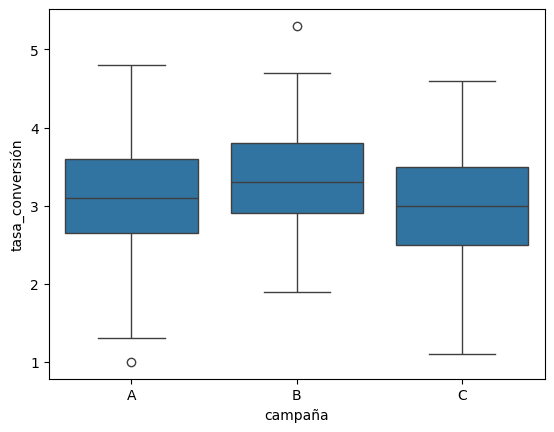

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df1, x='campaña', y='tasa_conversión');

La pregunta que queremos resolver con Tukey-HSD es: ¿dónde son mayores estas diferencias? ¿Entre A-B, A-C o B-C?

Así que usaremos la función "pairwise_tukey" para aplicar esta prueba:

In [4]:
# Prueba Tukey-HSD ANOVA 1 factor
from pingouin import pairwise_tukey

resultados = pairwise_tukey(
    data = df1, 
    dv = 'tasa_conversión', # la variable observada
    between = 'campaña', # el factor
    effsize = 'cohen', # equivalente al Cohen d usado en t-test
)
resultados

,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen
0,A,B,3.110345,3.311707,-0.201362,0.064404,-3.126564,5.259414e-03,-0.311514
1,A,C,3.110345,2.964356,0.145988,0.064641,2.258439,6.258599e-02,0.216153
2,B,C,3.311707,2.964356,0.347351,0.064484,5.386636,3.078447e-07,0.552398


Observaciones:

- Al comparar A-B y B-C obtenemos valores p ("p-tukey") menores que 0.05. **Esto quiere decir que hay diferencias significativas entre estos dos pares de grupos**

- Para la comparación A-C el valor p obtenido es 0.06 y por tanto **no hay diferencias significativas entre este par de grupos**

- Además, para las diferencias significativas observamos los siguientes tamaños de efecto ("cohen"):
    - Un tamaño del efecto negativo de 0.3 al comparar A-B: **la media de A es menor que la de B y el tamaño del efecto es pequeño**
    - Tamaño del efecto positivo de 0.5 al comparar B-C: **la media de B es mayor que la de C y el tamaño del efecto es mediano**


## 2. Aplicación al caso de ANOVA multifactorial

Supongamos que como Científicos de Datos estamos comparando el efecto que diferentes campañas de marketing (e-mails tipo A y B) y diferentes franjas horarias en las que se envían (mañana, tarde y noche) tienen en las tasas de conversión.

**¿La tasa de conversión depende del tipo de campaña, de la franja horaria, o de una combinación de ambos?**

Carguemos el set de datos usado en este ejemplo:

In [5]:
RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/37-2025-07-EstadisticaInferencialParametrica/10-estadistica-inf-param/release/anova_multifactorial_2x3.csv'

df2 = pd.read_csv(RUTA)
df2

,campaña,franja,tasa_conversion
0,A,mañana,2.149014
1,A,mañana,1.958521
2,A,mañana,2.194307
3,A,mañana,2.456909
4,A,mañana,1.929754
...,...,...,...
1195,B,noche,3.632142
1196,B,noche,3.494109
1197,B,noche,3.665747
1198,B,noche,3.567174


Y recordemos los resultados de la prueba ANOVA:

In [6]:
from pingouin import anova

resultados = anova(
    data = df2, # El dataset **EN EL FORMATO ADECUADO (tabla larga)**
    dv = "tasa_conversion", # La variable observada
    between = ["campaña", "franja"], # Los factores
    effsize = "n2", # La métrica para el tamaño del efecto (eta cuadrado)
    detailed = True, # Entregar tabla completa
)
resultados


,Source,SS,DF,MS,F,p-unc,n2
0,campaña,703.317729,1,703.317729,8023.290275,0.000000e+00,0.768146
1,franja,57.661059,2,28.830530,328.892189,1.659987e-114,0.062976
2,campaña * franja,49.959660,2,24.979830,284.964273,6.644049e-102,0.054565
3,Residual,104.665460,1194,0.087660,NaN,NaN,NaN


En este caso:

- Hay efectos principales debidos a "campaña" y a "franja"
- Hay efectos de interacción "campaña"-"franja"

En este caso podemos aplicar la prueba de Tukey a nivel de efectos principales y de efectos de interacción.

Comencemos aplicando la prueba Tukey-HSD al factor "campaña" (aunque esto es redundante, pues la campaña tiene sólo dos niveles (dos grupos) y la prueba ANOVA ya identificó diferencias significativas). Veamos el comparativo del efecto de la campaña de forma gráfica:

Text(0, 0.5, 'Tasa de conversión (%)')

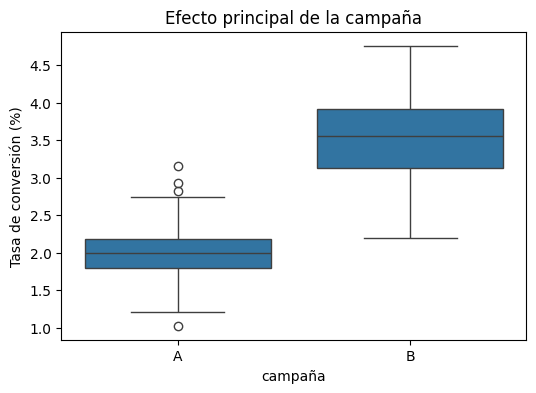

In [7]:
# Gráfico: efecto principal de campaña
plt.figure(figsize=(6, 4))
sns.boxplot(data=df2, x='campaña', y='tasa_conversion')
plt.title("Efecto principal de la campaña")
plt.ylabel("Tasa de conversión (%)")

Y ahora sí apliquemos la prueba Tukey-HSD **considerando únicamente este factor**:

In [8]:
# Prueba Tukey-HSD ANOVA multifactorial únicamente para el factor "campaña"
resultados = pairwise_tukey(
    data = df2, 
    dv = 'tasa_conversion', # la variable observada
    between = "campaña", # el factor
    effsize = 'cohen', # equivalente al Cohen d usado en t-test
)
resultados

,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen
0,A,B,1.995944,3.527085,-1.531141,0.024304,-63.000404,0.0,-3.63733


Lo anterior nos permite confirmar que:
- Hay diferencias significativas entre las medias de las dos campañas
- El tamaño del efecto es negativo (media en A menor que B) y dicho efecto es bastante grande.

En resumen: **La campaña B es mucho mejor que la campaña A en términos de la tasa de conversión**

Veamos qué ocurre con el segundo efecto ("franja"). Comencemos viendo el comportamiento de las medias de forma gráfica:

Text(0, 0.5, 'Tasa de conversión (%)')

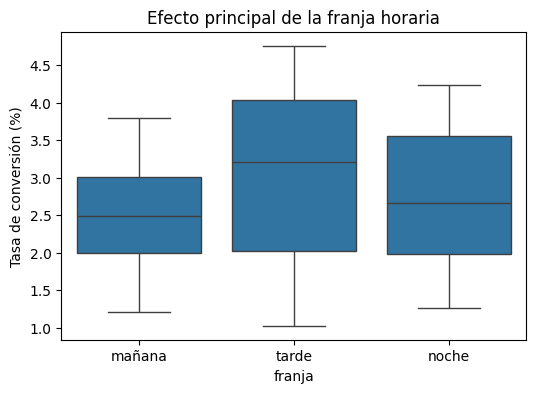

In [9]:
# Gráfico: efecto principal de franja horaria
plt.figure(figsize=(6, 4))
sns.boxplot(data=df2, x='franja', y='tasa_conversion')
plt.title("Efecto principal de la franja horaria")
plt.ylabel("Tasa de conversión (%)")

Al parecer las medianas de "mañana" y "noche" son comparables mientras que la de "tarde" es mayor. Veamos el resultado que arroja la prueba Tukey-HSD en este caso:

In [10]:
# Prueba Tukey-HSD ANOVA multifactorial únicamente para el factor "franja"
resultados = pairwise_tukey(
    data = df2, 
    dv = 'tasa_conversion', # la variable observada
    between = "franja", # el factor
    effsize = 'cohen', # equivalente al Cohen d usado en t-test
)
resultados

,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen
0,mañana,noche,2.495229,2.757197,-0.261967,0.059864,-4.376028,3.906010e-05,-0.361516
1,mañana,tarde,2.495229,3.032118,-0.536889,0.059864,-8.968443,7.871481e-14,-0.631903
2,noche,tarde,2.757197,3.032118,-0.274921,0.059864,-4.592416,1.443921e-05,-0.289270


En este caso vemos que:

- Entre todos los pares de franjas comparados hay diferencias significativas ("p-tukey" < 0.05)
- Al analizar la magnitud de los tamaños del efecto ("cohen") vemos que todos son pequeños o medianos

En resumen: **la franja horaria sí tiene un efecto en las tasas de conversión pero este efecto es pequeño o mediano comparado con el efecto de la campaña**

Y por último, veamos lo que ocurre con las interacciones. Recordemos estas interacciones de forma gráfica:

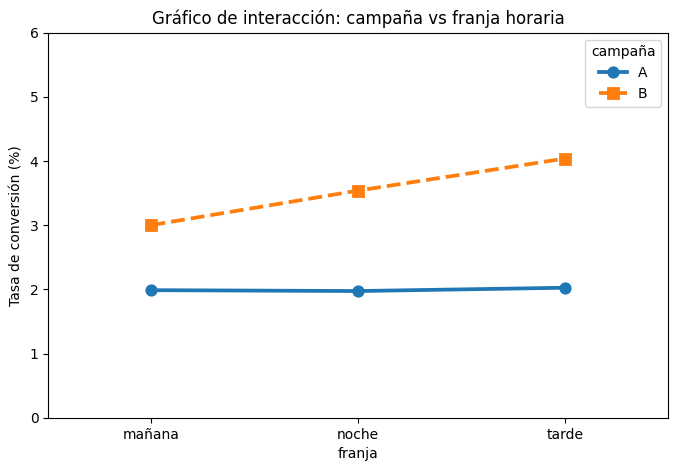

In [11]:
# Cálculo de medias por grupo para la interacción
medias_interacción = df2.groupby(['campaña', 'franja'])['tasa_conversion'].mean().reset_index()

# Gráfico de líneas de interacción
plt.figure(figsize=(8, 5))
sns.pointplot(
    data=medias_interacción,
    x='franja', # Eje horizontal: franja
    y='tasa_conversion', # Eje vertical: tasa de. conversión
    hue='campaña', # Color de la línea = tipo de campaña
    markers=['o', 's'],
    linestyles=['-', '--']
)
plt.title("Gráfico de interacción: campaña vs franja horaria")
plt.ylabel("Tasa de conversión (%)")
plt.ylim(0, 6);

En este caso la prueba será mucho más difícil de interpretar puesto que:

- Tendremos 6 posibles subgrupos campaña-franja: A-mañana, A-tarde, A-noche, B-mañana, B-tarde y B-noche
- Y la prueba Tukey-HSD comparará las medias **de todas las posibles combinaciones de estos 6 subgrupos**: ¡15 en total!

Así que la tabla de resultados tendrá precisamente 6 filas.

La función "pairwise_tukey" no permite introducir dos factores, así que tendremos que hacer un simple truco: 

- Crearemos una variable (una nueva columna) que contendrá las combinaciones de los factores "campaña" y "franja" para cada dato
- Así, podremos usar "pairwise_tukey" aplicado sobre esta variable como si fuese un ANOVA de un solo factor

Veamos primero cómo crear esta nueva columna:

In [12]:
df2['grupo'] = df2['campaña'] + ' - ' + df2['franja']
df2

,campaña,franja,tasa_conversion,grupo
0,A,mañana,2.149014,A - mañana
1,A,mañana,1.958521,A - mañana
2,A,mañana,2.194307,A - mañana
3,A,mañana,2.456909,A - mañana
4,A,mañana,1.929754,A - mañana
...,...,...,...,...
1195,B,noche,3.632142,B - noche
1196,B,noche,3.494109,B - noche
1197,B,noche,3.665747,B - noche
1198,B,noche,3.567174,B - noche


Y veamos todas las posibles combinaciones:

In [13]:
df2['grupo'].value_counts()

grupo
A - mañana    200
A - tarde     200
A - noche     200
B - mañana    200
B - tarde     200
B - noche     200
Name: count, dtype: int64

¡Perfecto! Ahora sí podemos usar Tukey-HSD usando esta columna como referencia:

In [14]:
resultados = pairwise_tukey(
    data = df2,
    dv = 'tasa_conversion',
    between = 'grupo',  # solo una variable ahora
    effsize = 'cohen'
)
resultados

,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen
0,A - mañana,A - noche,1.987769,1.974303,0.013465,0.029607,0.454793,9.975628e-01,0.046607
1,A - mañana,A - tarde,1.987769,2.025760,-0.037992,0.029607,-1.283186,7.943289e-01,-0.131997
2,A - mañana,B - mañana,1.987769,3.002690,-1.014921,0.029607,-34.279370,8.659740e-15,-3.465217
3,A - mañana,B - noche,1.987769,3.540090,-1.552321,0.029607,-52.430265,8.659740e-15,-5.269683
4,A - mañana,B - tarde,1.987769,4.038475,-2.050707,0.029607,-69.263435,8.659740e-15,-7.244643
5,A - noche,A - tarde,1.974303,2.025760,-0.051457,0.029607,-1.737979,5.067840e-01,-0.173163
6,A - noche,B - mañana,1.974303,3.002690,-1.028387,0.029607,-34.734163,8.659740e-15,-3.404501
7,A - noche,B - noche,1.974303,3.540090,-1.565786,0.029607,-52.885059,8.659740e-15,-5.155644
8,A - noche,B - tarde,1.974303,4.038475,-2.064172,0.029607,-69.718228,8.659740e-15,-7.055741
9,A - tarde,B - mañana,2.025760,3.002690,-0.976930,0.029607,-32.996184,8.659740e-15,-3.245329


¡Demasiada información!

Depuremos y organicemos un poco esta tabla para facilitar su interpretación.

Comencemos preservando únicamente aquellas filas cuyo "p-tukey" es menor que 0.05 (es decir aquellas combinaciones donde las diferencias son estadísticamente significativas):

In [15]:
resultados_f = resultados[resultados['p-tukey']<0.05]
resultados_f

,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen
2,A - mañana,B - mañana,1.987769,3.002690,-1.014921,0.029607,-34.279370,8.659740e-15,-3.465217
3,A - mañana,B - noche,1.987769,3.540090,-1.552321,0.029607,-52.430265,8.659740e-15,-5.269683
4,A - mañana,B - tarde,1.987769,4.038475,-2.050707,0.029607,-69.263435,8.659740e-15,-7.244643
6,A - noche,B - mañana,1.974303,3.002690,-1.028387,0.029607,-34.734163,8.659740e-15,-3.404501
7,A - noche,B - noche,1.974303,3.540090,-1.565786,0.029607,-52.885059,8.659740e-15,-5.155644
8,A - noche,B - tarde,1.974303,4.038475,-2.064172,0.029607,-69.718228,8.659740e-15,-7.055741
9,A - tarde,B - mañana,2.025760,3.002690,-0.976930,0.029607,-32.996184,8.659740e-15,-3.245329
10,A - tarde,B - noche,2.025760,3.540090,-1.514329,0.029607,-51.147079,8.659740e-15,-5.003259
11,A - tarde,B - tarde,2.025760,4.038475,-2.012715,0.029607,-67.980249,8.659740e-15,-6.905208
12,B - mañana,B - noche,3.002690,3.540090,-0.537400,0.029607,-18.150896,8.659740e-15,-1.747706


Ahora preservemos únicamente las columnas "A", "B" 8 "cohen":

In [16]:
resultados_f = resultados_f[['A', 'B', 'cohen']]
resultados_f

,A,B,cohen
2,A - mañana,B - mañana,-3.465217
3,A - mañana,B - noche,-5.269683
4,A - mañana,B - tarde,-7.244643
6,A - noche,B - mañana,-3.404501
7,A - noche,B - noche,-5.155644
8,A - noche,B - tarde,-7.055741
9,A - tarde,B - mañana,-3.245329
10,A - tarde,B - noche,-5.003259
11,A - tarde,B - tarde,-6.905208
12,B - mañana,B - noche,-1.747706


Y podemos enfocarnos en las comparaciones donde los tamaños del efecto (valor absoluto) son más grandes. Esto equivale a ordenar el DataFrame anterior usando como referencia la columna "cohen" y de manera descendente:

In [17]:
resultados_f = resultados_f.sort_values(by='cohen', ascending=True)
resultados_f

,A,B,cohen
4,A - mañana,B - tarde,-7.244643
8,A - noche,B - tarde,-7.055741
11,A - tarde,B - tarde,-6.905208
3,A - mañana,B - noche,-5.269683
7,A - noche,B - noche,-5.155644
10,A - tarde,B - noche,-5.003259
13,B - mañana,B - tarde,-3.493612
2,A - mañana,B - mañana,-3.465217
6,A - noche,B - mañana,-3.404501
9,A - tarde,B - mañana,-3.245329


Y con esto ya podemos intentar interpretar algunos resultados. Tomemos las 6 primeras filas:

En todos los casos las combinaciones A-cualquier franja tienen medias menores que las combinaciones B-tarde o B-noche y el tamaño del efecto es grande en estos casos.

Esto nos permite concluir que **la mejor combinación (en términos de obtener el mayor promedio en las tasas de conversión) es la combinación de la campaña B con envíos en las franjas tarde o noche**

Por otra parte, vemos queen la tabla anterior no aparecen pares de combinaciones que contengan únicamente la campaña A, lo que nos permite reafirmar lo analizado anteriormente: la campaña A no es mejor que la campaña B en términos de las tasas de conversión.